### FIFA World Cup 2026 - Consumer Spending Accommodations and Food EDA
#### Exploring restaurant and hotel spending trends across host and control cities

In [62]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [56]:
# Loading in data
df = pd.read_csv("../data/raw/Affinity - City - Monthly.csv")
cities = pd.read_csv("../data/raw/GeoIDs - City.csv")
print(df.shape)
print(cities.shape)
print(df.head())
print(cities.head())

(4004, 42)
(53, 8)
   year  month  day_endofmonth  cityid freq  spend_aap  spend_s_aap  \
0  2020      1              31       1    m        0.0          0.0   
1  2020      1              31       2    m        0.0          0.0   
2  2020      1              31       3    m        0.0          0.0   
3  2020      1              31       4    m        0.0          0.0   
4  2020      1              31       5    m        0.0          0.0   

      spend_acf   spend_s_acf  spend_aer  ...  spend_s_sgh  spend_tws  \
0 -1.980000e-08  1.820000e-08        0.0  ...          0.0        0.0   
1  2.830000e-09 -3.830000e-08        0.0  ...          0.0        0.0   
2  4.270000e-08  4.270000e-08        0.0  ...          0.0        0.0   
3  3.610000e-08  0.000000e+00        0.0  ...          0.0        0.0   
4  2.240000e-08  0.000000e+00        0.0  ...          0.0        0.0   

   spend_s_tws  spend_inperson  spend_s_inperson  spend_retail_no_grocery  \
0          0.0    1.480000e-08      1.

In [57]:
# Data cleaning and filtering

# Filtering df to only include necessary columns, cities of interest, and dates

df_filtered = df[['year', 'month', 'day_endofmonth', 'cityid', 'spend_all', 'spend_acf']]
df_filtered['spend_acf'].dtype
df_filtered.replace('.', np.nan, inplace=True)
df_filtered = df_filtered.dropna()
#print(df_filtered.head())

# Filter cities dataframe for necessary features
cities_filtered = cities[['cityid', 'cityname', 'stateabbrev', 'city_pop2019']]
#print(cities_filtered.head())

# merging dataframse to match cityid to cities
df_merged = pd.merge(df_filtered, cities_filtered, on='cityid')
#print(df_merged.head())

# Filter to cities of interest 
target_cities = ['Los Angeles', 'Denver', 'Dallas', 'Chicago', 'Boston', 'Atlanta', 'Kansas City', 'Austin', 'Charlotte']
worldcup_city_spending = df_merged[df_merged['cityname'].isin(target_cities)]
#print(worldcup_city_spending.head())

# Adding a date column
worldcup_city_spending = worldcup_city_spending.rename(columns={'day_endofmonth': 'day'})
worldcup_city_spending['Date'] = pd.to_datetime(worldcup_city_spending[['year', 'month', 'day']])
#print(worldcup_city_spending.iloc[14:44])

# Removing unnecessary columns and setting date as index
worldcup_city_spending = worldcup_city_spending.drop(columns=['year', 'month', 'day', 'cityid'])
worldcup_city_spending = worldcup_city_spending.set_index('Date')
print(worldcup_city_spending)

worldcup_city_spending.groupby('cityname').size()


            spend_all     spend_acf     cityname stateabbrev  city_pop2019
Date                                                                      
2020-01-31      0.000 -1.980000e-08  Los Angeles          CA      10039107
2020-01-31      0.000  4.270000e-08      Chicago          IL       5150233
2020-01-31      0.000  4.620000e-08       Dallas          TX       2635516
2020-01-31      0.000  1.660000e-08       Austin          TX       1273954
2020-01-31      0.000  0.000000e+00    Charlotte          NC       1110356
...               ...           ...          ...         ...           ...
2026-05-31      0.166  6.680000e-02    Charlotte          NC       1110356
2026-05-31      0.443  2.690000e-01       Boston          MA        803907
2026-05-31      0.199  6.880000e-02       Denver          CO        727211
2026-05-31      0.328  1.950000e-01      Atlanta          GA       1063937
2026-05-31      0.228  3.290000e-01  Kansas City          MO        703011

[693 rows x 5 columns]


cityname
Atlanta        77
Austin         77
Boston         77
Charlotte      77
Chicago        77
Dallas         77
Denver         77
Kansas City    77
Los Angeles    77
dtype: int64

In [58]:
# Data Cleaning

worldcup_city_spending.dtypes

spend_all       float64
spend_acf       float64
cityname         object
stateabbrev      object
city_pop2019      int64
dtype: object

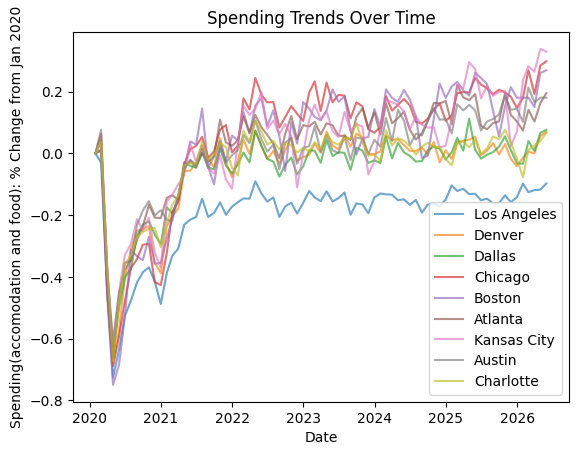

<Figure size 1200x600 with 0 Axes>

In [59]:
# Creating line plots for each city to visualize spending trends over time

for city in target_cities:
    city_data = worldcup_city_spending[worldcup_city_spending['cityname'] == city]
    plt.plot(city_data.index, city_data['spend_acf'], label = city, alpha = 0.65)
    plt.title(f"Spending Trends Over Time")
    plt.xlabel("Date")
    plt.ylabel("Spending(accomodation and food): % Change from Jan 2020")
    plt.legend()
plt.figure(figsize = (12, 6))
plt.show()
plt.close()

This line plot shows consumer spending on accommodations and food from January 2020 to May 2026 (right before the world cup) in percent change in relation to January 2020. All 9 cities experience a sharp decline in consumer spending in 2020 due to the COVID pandemic. After this period all cities experienced increased consumer spending on accommodations and food. Economic recovery varied by city with Kansas City being at the top of consumer spending and Los Angeles lagging behind other cities. We can see consumer spending on food and accommodations dips around the start of each year suggesting a consistent seasonal pattern in restaurant and hotel spending, strengthening the use of a seasonal time series model for forecasting.

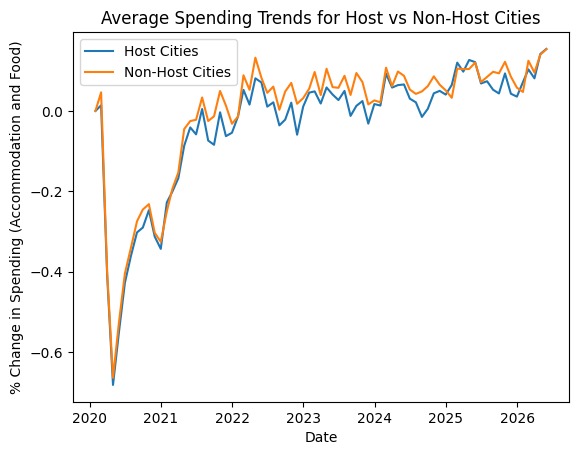

In [60]:
# Comparing host and non-host cities to see if there is a significant difference in spending trends

# Df of host cities 
host_cities = ['Los Angeles', 'Atlanta', 'Dallas', 'Boston', 'Kansas City']
df_host = worldcup_city_spending[worldcup_city_spending['cityname'].isin(host_cities)]
# Df of non-host cities
nonhost_cities = ['Denver', 'Chicago', 'Austin', 'Charlotte']
df_nonhost = worldcup_city_spending[worldcup_city_spending['cityname'].isin(nonhost_cities)]

# Finding average spending for host and non-host cities by date
host_avg = df_host.groupby("Date")['spend_acf'].mean()
nonhost_avg = df_nonhost.groupby("Date")['spend_acf'].mean()

# Line graph to show average spending trends for host and control (non-host) cities
plt.plot(host_avg.index, host_avg, label = "Host Cities")
plt.plot(nonhost_avg.index, nonhost_avg, label = "Non-Host Cities")
plt.title("Average Spending Trends for Host vs Non-Host Cities")
plt.xlabel("Date")
plt.ylabel("% Change in Spending (Accommodation and Food)")
plt.legend()

Host and non-host cities track closely in historical restaurant and hotel spending patterns, validating the control group selection. Since both groups behaved similarly before the World Cup, any significant divergence in spending during June and July 2026 can be attributed to the World Cup rather than pre-existing differences between cities.
